# Projet Deep Learning — EMSI 2025-2026
## Partie I : MLP et Ingénierie PyTorch
### Dataset : Breast Cancer Wisconsin

Ce notebook couvre l'ensemble des exigences de la Partie I :
- Exploration et prétraitement des données
- Construction de deux versions du MLP (`nn.Sequential` et classe personnalisée)
- Inspection des paramètres
- Comparaison de 3 stratégies d'initialisation
- Sauvegarde / rechargement du modèle
- Entraînement, évaluation et matrice de confusion


## Cellule 1 — IMPORTS ET CONFIGURATION

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

Device utilisé : cpu


## Cellule 2 — EXPLORATION DU DATASET

EXPLORATION DU DATASET
Nombre d'échantillons   : 569
Nombre de features      : 30
Classes                 : ['malignant' 'benign']
Distribution des classes: [212 357]
  → malignant (0): 212
  → benign    (1): 357
Valeurs manquantes      : 0

Statistiques des 5 premières features :
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count      569.000       569.000         569.000    569.000          569.000
mean        14.127        19.290          91.969    654.889            0.096
std          3.524         4.301          24.299    351.914            0.014
min          6.981         9.710          43.790    143.500            0.053
25%         11.700        16.170          75.170    420.300            0.086
50%         13.370        18.840          86.240    551.100            0.096
75%         15.780        21.800         104.100    782.700            0.105
max         28.110        39.280         188.500   2501.000            0.163


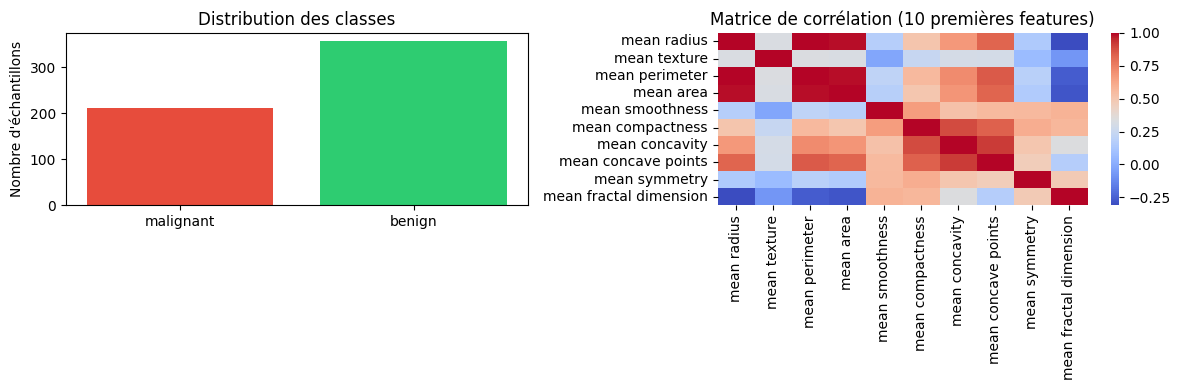

Figure sauvegardée : exploration_dataset.png


In [19]:

data = load_breast_cancer()
X, y = data.data, data.target

print("=" * 50)
print("EXPLORATION DU DATASET")
print("=" * 50)
print(f"Nombre d'échantillons   : {X.shape[0]}")
print(f"Nombre de features      : {X.shape[1]}")
print(f"Classes                 : {data.target_names}")
print(f"Distribution des classes: {np.bincount(y)}")
print(f"  → malignant (0): {np.sum(y==0)}")
print(f"  → benign    (1): {np.sum(y==1)}")
print(f"Valeurs manquantes      : {np.isnan(X).sum()}")
print()

df = pd.DataFrame(X, columns=data.feature_names)
print("Statistiques des 5 premières features :")
print(df.iloc[:, :5].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(data.target_names, np.bincount(y), color=['#e74c3c', '#2ecc71'])
axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre d'échantillons")

corr = df.iloc[:, :10].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Matrice de corrélation (10 premières features)")

plt.tight_layout()
plt.savefig("exploration_dataset.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : exploration_dataset.png")

## Cellule 3 — PRÉTRAITEMENT ET SÉPARATION DES DONNÉES

In [20]:



X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("PRÉTRAITEMENT TERMINÉ")
print(f"  Train : {X_train.shape} — {np.bincount(y_train)}")
print(f"  Val   : {X_val.shape}   — {np.bincount(y_val)}")
print(f"  Test  : {X_test.shape}  — {np.bincount(y_test)}")

def numpy_to_dataloader(X, y, batch_size=32, shuffle=False):
    """Convertit numpy arrays en DataLoader PyTorch."""
    X_t = torch.FloatTensor(X)
    y_t = torch.LongTensor(y)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = numpy_to_dataloader(X_train, y_train, batch_size=32, shuffle=True)
val_loader   = numpy_to_dataloader(X_val,   y_val,   batch_size=32, shuffle=False)
test_loader  = numpy_to_dataloader(X_test,  y_test,  batch_size=32, shuffle=False)
print("DataLoaders créés ✓")

PRÉTRAITEMENT TERMINÉ
  Train : (398, 30) — [148 250]
  Val   : (85, 30)   — [32 53]
  Test  : (86, 30)  — [32 54]
DataLoaders créés ✓


## Cellule 4 — VERSION 1 : MLP avec nn.Sequential

In [21]:




net_sequential = nn.Sequential(
    nn.Linear(30, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2)
)

print("VERSION 1 : MLP Sequential")
print(net_sequential)
print(f"\nNombre total de paramètres : "
      f"{sum(p.numel() for p in net_sequential.parameters())}")

VERSION 1 : MLP Sequential
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)

Nombre total de paramètres : 4130


## Cellule 5 — VERSION 2 : MLP avec classe personnalisée

In [22]:





class MLP(nn.Module):
    def __init__(self, input_dim=30, hidden1=64, hidden2=32, output_dim=2):
        super().__init__()

        self.fc1     = nn.Linear(input_dim, hidden1)
        self.fc2     = nn.Linear(hidden1, hidden2)
        self.fc3     = nn.Linear(hidden2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h1 = self.dropout(h1)

        h2 = F.relu(self.fc2(h1))
        h2 = self.dropout(h2)

        out = self.fc3(h2)
        return out

model = MLP()
print("VERSION 2 : MLP Classe personnalisée")
print(model)

VERSION 2 : MLP Classe personnalisée
MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## Cellule 6 — INSPECTION DES PARAMÈTRES

In [23]:




print("=" * 50)
print("INSPECTION DES PARAMÈTRES")
print("=" * 50)

print("\nTous les paramètres (named_parameters) :")
for name, param in model.named_parameters():
    print(f"  {name:20s} | shape={str(param.shape):25s} | requires_grad={param.requires_grad}")

print("\nDétail de fc1 (première couche) :")
print(f"  Poids (weight) shape : {model.fc1.weight.shape}")
print(f"  Biais  (bias)  shape : {model.fc1.bias.shape}")
print(f"  Gradient avant backward : {model.fc1.weight.grad}")

print("\nstate_dict (clés) :")
for key in model.state_dict().keys():
    print(f"  {key}")

INSPECTION DES PARAMÈTRES

Tous les paramètres (named_parameters) :
  fc1.weight           | shape=torch.Size([64, 30])      | requires_grad=True
  fc1.bias             | shape=torch.Size([64])          | requires_grad=True
  fc2.weight           | shape=torch.Size([32, 64])      | requires_grad=True
  fc2.bias             | shape=torch.Size([32])          | requires_grad=True
  fc3.weight           | shape=torch.Size([2, 32])       | requires_grad=True
  fc3.bias             | shape=torch.Size([2])           | requires_grad=True

Détail de fc1 (première couche) :
  Poids (weight) shape : torch.Size([64, 30])
  Biais  (bias)  shape : torch.Size([64])
  Gradient avant backward : None

state_dict (clés) :
  fc1.weight
  fc1.bias
  fc2.weight
  fc2.bias
  fc3.weight
  fc3.bias


## Cellule 7 — TROIS STRATÉGIES D'INITIALISATION

Gaussienne (std=0.01): mean=-0.0001, std=0.0100
Constante (val=1.0): mean=1.0000, std=0.0000
Xavier Uniform: mean=0.0040, std=0.1454


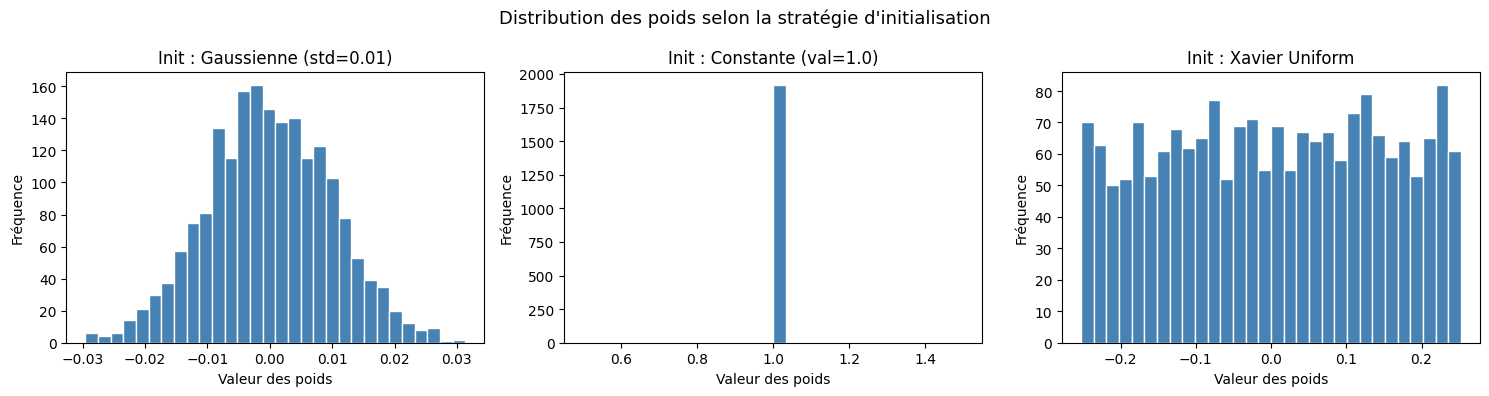

Figure sauvegardée : initialisations.png


In [24]:





def init_gaussienne(module):
    """Poids ~ N(0, 0.01), biais = 0"""
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0, std=0.01)
        nn.init.zeros_(module.bias)

def init_constante(module):
    """Tous les poids = 1.0, biais = 0 → MAUVAIS en pratique (symétrie)"""
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 1.0)
        nn.init.zeros_(module.bias)

def init_xavier(module):
    """Xavier uniform : stabilise la variance des signaux → RECOMMANDÉ"""
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
init_names = ["Gaussienne (std=0.01)", "Constante (val=1.0)", "Xavier Uniform"]
init_fns   = [init_gaussienne, init_constante, init_xavier]

for ax, name, fn in zip(axes, init_names, init_fns):
    test_model = MLP()
    test_model.apply(fn)
    weights = test_model.fc1.weight.data.numpy().flatten()
    ax.hist(weights, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f"Init : {name}")
    ax.set_xlabel("Valeur des poids")
    ax.set_ylabel("Fréquence")
    print(f"{name}: mean={weights.mean():.4f}, std={weights.std():.4f}")

plt.suptitle("Distribution des poids selon la stratégie d'initialisation", fontsize=13)
plt.tight_layout()
plt.savefig("initialisations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : initialisations.png")

## Cellule 8 — FONCTION D'ENTRAÎNEMENT COMPLÈTE

In [37]:





def entrainer_modele(model, train_loader, val_loader,
                     epochs=80, lr=1e-3, verbose=True):
    """
    Entraîne le modèle et retourne l'historique des métriques.

    Args:
        model       : le réseau de neurones (nn.Module)
        train_loader: DataLoader d'entraînement
        val_loader  : DataLoader de validation
        epochs      : nombre d'époques
        lr          : learning rate
        verbose     : afficher les logs tous les 10 epochs

    Returns:
        history : dict avec train_loss, val_loss, val_acc
        model   : modèle entraîné (déplacé sur device)
    """
    model = model.to(device)


    criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state   = None

    for epoch in range(epochs):

        model.train()
        train_loss_total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()


        model.eval()
        val_loss_total = 0
        correct = 0
        total   = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss    = criterion(outputs, y_batch)

                val_loss_total += loss.item()
                preds    = outputs.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)

        avg_train_loss = train_loss_total / len(train_loader)
        avg_val_loss   = val_loss_total   / len(val_loader)
        val_acc        = correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"train_loss={avg_train_loss:.4f} | "
                  f"val_loss={avg_val_loss:.4f} | "
                  f"val_acc={val_acc:.4f}")


    model.load_state_dict(best_state)
    print(f"\nMeilleure val_acc : {best_val_acc:.4f}")
    return history, model

## Cellule 9 — COMPARAISON DES 3 INITIALISATIONS

COMPARAISON DES INITIALISATIONS

→ Initialisation : Gaussienne

Meilleure val_acc : 0.9882
  Meilleure val_acc = 0.9882

→ Initialisation : Constante

Meilleure val_acc : 0.9529
  Meilleure val_acc = 0.9529

→ Initialisation : Xavier

Meilleure val_acc : 0.9882
  Meilleure val_acc = 0.9882


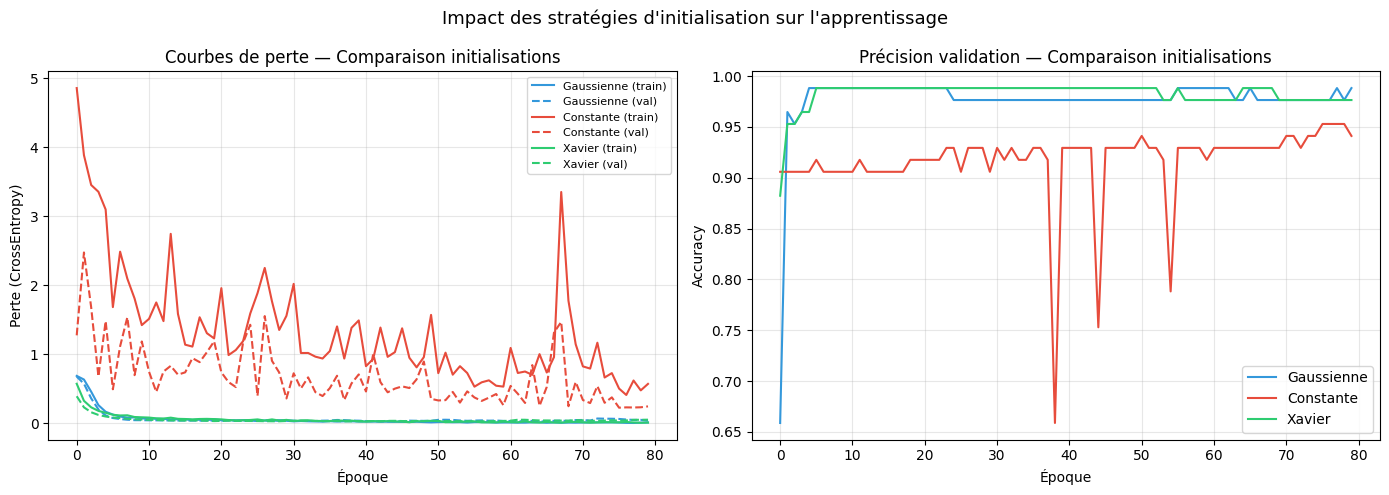

Figure sauvegardée : comparaison_initialisations.png


In [27]:
print("=" * 50)
print("COMPARAISON DES INITIALISATIONS")
print("=" * 50)

resultats_init = {}
init_configs = {
    "Gaussienne": init_gaussienne,
    "Constante" : init_constante,
    "Xavier"    : init_xavier
}

for nom, fn_init in init_configs.items():
    print(f"\n→ Initialisation : {nom}")
    m = MLP()
    m.apply(fn_init)
    hist, _ = entrainer_modele(m, train_loader, val_loader,
                                epochs=80, verbose=False)
    final_val_acc = max(hist['val_acc'])
    print(f"  Meilleure val_acc = {final_val_acc:.4f}")
    resultats_init[nom] = hist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Gaussienne': '#3498db', 'Constante': '#e74c3c', 'Xavier': '#2ecc71'}

for nom, hist in resultats_init.items():
    axes[0].plot(hist['train_loss'], label=f"{nom} (train)", color=colors[nom], linestyle='-')
    axes[0].plot(hist['val_loss'],   label=f"{nom} (val)",   color=colors[nom], linestyle='--')
    axes[1].plot(hist['val_acc'],    label=nom,              color=colors[nom])

axes[0].set_title("Courbes de perte — Comparaison initialisations")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Perte (CrossEntropy)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Précision validation — Comparaison initialisations")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Impact des stratégies d'initialisation sur l'apprentissage", fontsize=13)
plt.tight_layout()
plt.savefig("comparaison_initialisations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : comparaison_initialisations.png")

## Cellule 10 — ENTRAÎNEMENT FINAL AVEC XAVIER (meilleure init)

ENTRAÎNEMENT FINAL (Xavier)
Epoch  10/100 | train_loss=0.1063 | val_loss=0.0659 | val_acc=0.9882
Epoch  20/100 | train_loss=0.0835 | val_loss=0.0412 | val_acc=0.9882
Epoch  30/100 | train_loss=0.0444 | val_loss=0.0330 | val_acc=0.9882
Epoch  40/100 | train_loss=0.0394 | val_loss=0.0335 | val_acc=0.9765
Epoch  50/100 | train_loss=0.0190 | val_loss=0.0277 | val_acc=0.9765
Epoch  60/100 | train_loss=0.0277 | val_loss=0.0249 | val_acc=0.9765
Epoch  70/100 | train_loss=0.0197 | val_loss=0.0292 | val_acc=0.9765
Epoch  80/100 | train_loss=0.0194 | val_loss=0.0307 | val_acc=0.9882
Epoch  90/100 | train_loss=0.0125 | val_loss=0.0366 | val_acc=0.9765
Epoch 100/100 | train_loss=0.0132 | val_loss=0.0305 | val_acc=0.9765

Meilleure val_acc : 0.9882


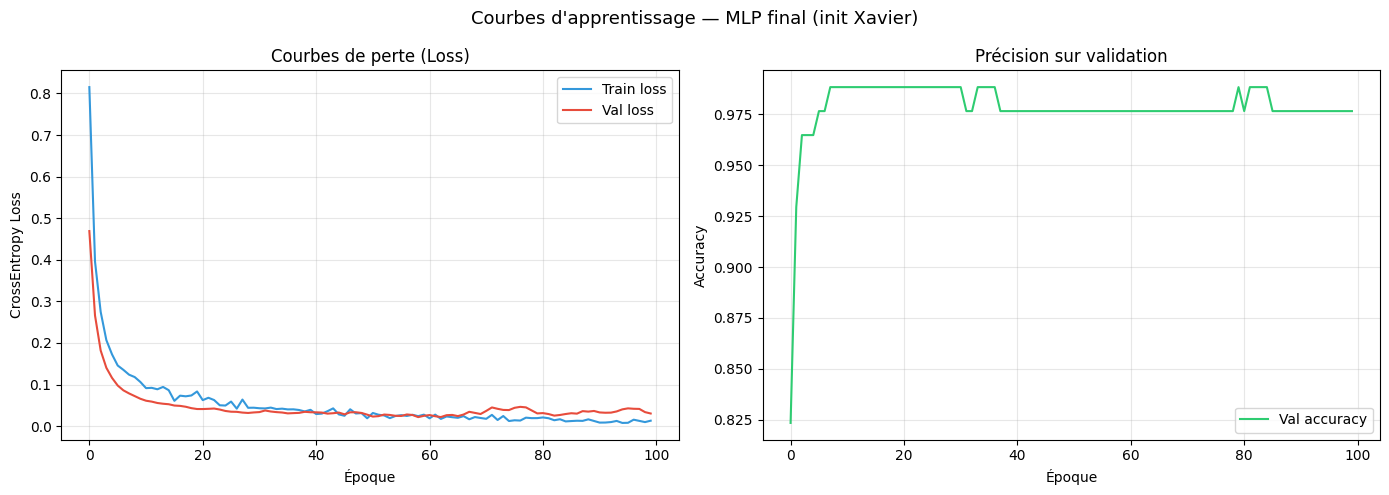

Figure sauvegardée : courbes_apprentissage.png


In [28]:
print("=" * 50)
print("ENTRAÎNEMENT FINAL (Xavier)")
print("=" * 50)

modele_final = MLP()
modele_final.apply(init_xavier)

historique, modele_final = entrainer_modele(
    modele_final, train_loader, val_loader, epochs=100, verbose=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historique['train_loss'], label='Train loss', color='#3498db')
axes[0].plot(historique['val_loss'],   label='Val loss',   color='#e74c3c')
axes[0].set_title("Courbes de perte (Loss)")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historique['val_acc'], label='Val accuracy', color='#2ecc71')
axes[1].set_title("Précision sur validation")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — MLP final (init Xavier)", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : courbes_apprentissage.png")

## Cellule 11 — SAUVEGARDE ET RECHARGEMENT DU MODÈLE

In [29]:



chemin = "mlp_breast_cancer.pth"
torch.save(modele_final.state_dict(), chemin)
print(f"Modèle sauvegardé dans : {chemin}")

modele_recharge = MLP()
modele_recharge.load_state_dict(torch.load(chemin))
modele_recharge.eval()
print("Modèle rechargé et prêt pour l'inférence ✓")

X_test_tensor = torch.FloatTensor(X_test[:5]).to(device)
with torch.no_grad():
    out_original = modele_final.to(device)(X_test_tensor)
    out_recharge = modele_recharge.to(device)(X_test_tensor)
    identique = torch.allclose(out_original, out_recharge)
    print(f"Sorties identiques : {identique} ✓")

Modèle sauvegardé dans : mlp_breast_cancer.pth
Modèle rechargé et prêt pour l'inférence ✓
Sorties identiques : True ✓


## Cellule 12 — DÉMONSTRATION DU GRADIENT

In [30]:



demo_model = MLP().to(device)
demo_model.apply(init_xavier)
demo_model.train()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(demo_model.parameters(), lr=1e-3)

X_demo = torch.FloatTensor(X_train[:32]).to(device)
y_demo = torch.LongTensor(y_train[:32]).to(device)

print("DÉMONSTRATION DU GRADIENT")
print(f"Gradient fc1.weight AVANT backward : {demo_model.fc1.weight.grad}")

optimizer.zero_grad()
outputs = demo_model(X_demo)
loss = criterion(outputs, y_demo)
loss.backward()

print(f"Gradient fc1.weight APRÈS backward  : shape={demo_model.fc1.weight.grad.shape}")
print(f"  Exemple valeur grad[0,0] : {demo_model.fc1.weight.grad[0,0]:.6f}")
print(f"  Norme du gradient       : {demo_model.fc1.weight.grad.norm():.4f}")

DÉMONSTRATION DU GRADIENT
Gradient fc1.weight AVANT backward : None
Gradient fc1.weight APRÈS backward  : shape=torch.Size([64, 30])
  Exemple valeur grad[0,0] : -0.002968
  Norme du gradient       : 1.1624


## Cellule 13 — ÉVALUATION SUR LE TEST SET

In [31]:



def evaluer_modele(model, loader, device):
    """Évalue le modèle et retourne les prédictions et labels réels."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluer_modele(modele_final, test_loader, device)

print("=" * 50)
print("ÉVALUATION FINALE SUR LE TEST SET")
print("=" * 50)
print(f"\nAccuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
print()
print("Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=data.target_names))

ÉVALUATION FINALE SUR LE TEST SET

Accuracy  : 0.9070
Precision : 0.9107
Recall    : 0.9444
F1-Score  : 0.9273

Rapport de classification :
              precision    recall  f1-score   support

   malignant       0.90      0.84      0.87        32
      benign       0.91      0.94      0.93        54

    accuracy                           0.91        86
   macro avg       0.91      0.89      0.90        86
weighted avg       0.91      0.91      0.91        86



## Cellule 14 — MATRICE DE CONFUSION

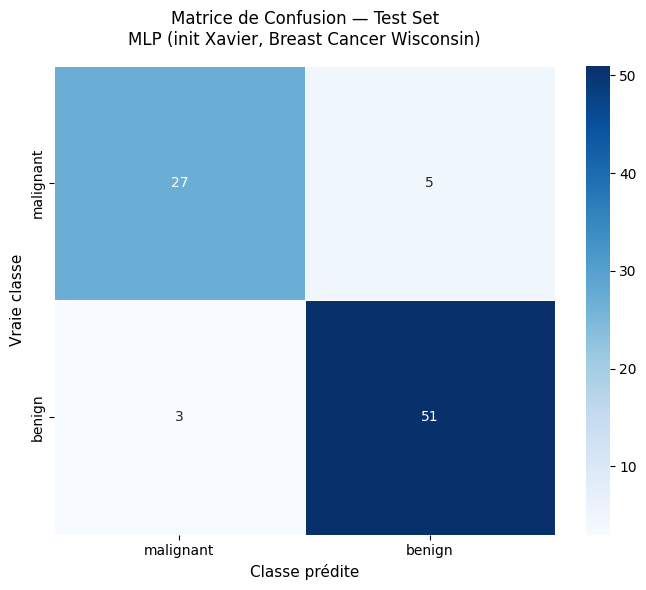

Figure sauvegardée : matrice_confusion.png


In [32]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            linewidths=0.5, ax=ax)
ax.set_title("Matrice de Confusion — Test Set\nMLP (init Xavier, Breast Cancer Wisconsin)",
             fontsize=12, pad=15)
ax.set_ylabel("Vraie classe", fontsize=11)
ax.set_xlabel("Classe prédite", fontsize=11)

plt.tight_layout()
plt.savefig("matrice_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : matrice_confusion.png")

## Cellule 15 — VÉRIFICATION GPU / CPU

In [33]:



print("=" * 50)
print("UTILISATION DU DEVICE")
print("=" * 50)
print(f"Device sélectionné : {device}")
print(f"GPU disponible     : {torch.cuda.is_available()}")

modele_gpu = MLP().to(device)
X_gpu      = torch.FloatTensor(X_test[:5]).to(device)

with torch.no_grad():
    sortie = modele_gpu(X_gpu)

print(f"Device du modèle  : next(modele_gpu.parameters()).device")
print(f"                  → {next(modele_gpu.parameters()).device}")
print(f"Device des données: {X_gpu.device}")
print(f"Device de la sortie: {sortie.device}")
print("→ Tout est sur le même device ✓")

UTILISATION DU DEVICE
Device sélectionné : cpu
GPU disponible     : False
Device du modèle  : next(modele_gpu.parameters()).device
                  → cpu
Device des données: cpu
Device de la sortie: cpu
→ Tout est sur le même device ✓


## Cellule 16 — TABLEAU RÉCAPITULATIF FINAL

In [34]:
print("\n" + "=" * 55)
print("RÉCAPITULATIF — PARTIE I : MLP BREAST CANCER WISCONSIN")
print("=" * 55)

print("\n1. ARCHITECTURE")
print("   Version Sequential : Linear(30→64) + ReLU + Dropout(0.3)")
print("                        + Linear(64→32) + ReLU + Dropout(0.3)")
print("                        + Linear(32→2)")
print("   Version Classe      : identique, plus flexible")
total_params = sum(p.numel() for p in modele_final.parameters())
print(f"   Paramètres totaux   : {total_params}")

print("\n2. INITIALISATIONS TESTÉES")
for nom, hist in resultats_init.items():
    print(f"   {nom:12s} → meilleure val_acc = {max(hist['val_acc']):.4f}")

print("\n3. RÉSULTATS TEST SET")
print(f"   Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"   Precision : {precision_score(y_true, y_pred):.4f}")
print(f"   Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"   F1-Score  : {f1_score(y_true, y_pred):.4f}")

print("\n4. FICHIERS PRODUITS")
print("   - exploration_dataset.png")
print("   - initialisations.png")
print("   - comparaison_initialisations.png")
print("   - courbes_apprentissage.png")
print("   - matrice_confusion.png")
print("   - mlp_breast_cancer.pth  (modèle sauvegardé)")
print()
print("PARTIE I TERMINÉE ✓")


RÉCAPITULATIF — PARTIE I : MLP BREAST CANCER WISCONSIN

1. ARCHITECTURE
   Version Sequential : Linear(30→64) + ReLU + Dropout(0.3)
                        + Linear(64→32) + ReLU + Dropout(0.3)
                        + Linear(32→2)
   Version Classe      : identique, plus flexible
   Paramètres totaux   : 4130

2. INITIALISATIONS TESTÉES
   Gaussienne   → meilleure val_acc = 0.9882
   Constante    → meilleure val_acc = 0.9529
   Xavier       → meilleure val_acc = 0.9882

3. RÉSULTATS TEST SET
   Accuracy  : 0.9070
   Precision : 0.9107
   Recall    : 0.9444
   F1-Score  : 0.9273

4. FICHIERS PRODUITS
   - exploration_dataset.png
   - initialisations.png
   - comparaison_initialisations.png
   - courbes_apprentissage.png
   - matrice_confusion.png
   - mlp_breast_cancer.pth  (modèle sauvegardé)

PARTIE I TERMINÉE ✓
